# AI for Chemistry — Week 09, Session B
## Workshop: a generative RNN for SMILES — sample and assess validity

**Course:** AI for Chemistry · **Session:** 09B (hands-on workshop, 2.0 h) ·
**Runtime:** ~30-40 s on laptop CPU (40 training epochs).

### Suggested timing (solo study, ~120 min)

| Section | Topic | Time |
|--------:|-------|-----:|
| 0 | Setup: tokeniser, training-epoch budget | 10 min |
| 1 | Training a character-level generative RNN | 20 min |
| 2 | Sampling and assessing validity | 20 min |
| 3 | Temperature: the validity/diversity trade-off | 20 min |
| 4 | Do generated molecules resemble the training distribution? | 15 min |
| 5 | Exercises (3) + mini-challenge | 35 min |

### Learning objectives
1. Train a character-level LSTM as an autoregressive SMILES generator, using
   Week 08's causal-prediction framing directly (`next-token prediction`). *(LO7)*
2. Sample new SMILES strings with temperature-controlled multinomial
   sampling. *(LO7)*
3. Assess generated molecules by the standard **validity / uniqueness /
   novelty** trio, and quantify the validity/diversity trade-off across
   temperatures. *(LO4, LO7)*
4. Sanity-check a generative model by comparing generated-molecule property
   distributions to the training set's. *(LO4, LO8)*

### Prerequisites — before this notebook you should be able to
- Week 08A: tokenisation, embeddings, causal (autoregressive) masking.
- Week 09A: why sampling a generative model's output needs validity checks.

### How to use this notebook (solo study)
Read, run, check each **✅** cell in order. This is the **solutions**
notebook.


---
## 0. Setup: tokeniser, training-epoch budget

**What to look for:** `RDKit available: True`; `N_EPOCHS = 40`; a vocabulary
including `<start>`/`<end>` marker tokens alongside Week 08A's character
set.


In [1]:
try:
    import rdkit
    print("RDKit available:", True, " version", rdkit.__version__)
except ImportError as exc:
    raise SystemExit("RDKit is not installed; see env/environment.yml.") from exc


RDKit available: True  version 2026.03.5


In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors
RDLogger.DisableLog("rdApp.*")

SEED = 0xC0FFEE
np.random.seed(SEED)
torch.manual_seed(SEED)

N_EPOCHS = 40      # keeps training comfortably inside a laptop CPU's session budget
print(f"N_EPOCHS = {N_EPOCHS}")

ROOT = Path.cwd()
while not (ROOT / "sources").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / "sources" / "datasets"
FIGDIR = ROOT / "lectures" / "week-09_generative-models-xai" / "slides" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

esol = pd.read_csv(DATA / "esol_clean.csv")
train_smiles = esol["canonical_smiles"].tolist()

START, END, PAD = "^", "$", "_"                 # 3 special tokens, disjoint from any SMILES char
chars = sorted(set("".join(train_smiles)))
vocab = [PAD, START, END] + chars
stoi = {c: i for i, c in enumerate(vocab)}
itos = {i: c for c, i in stoi.items()}
VOCAB_SIZE = len(vocab)
MAX_LEN = max(len(s) for s in train_smiles) + 2      # +2 for start/end markers

def encode(smiles, max_len=MAX_LEN):
    """SMILES -> fixed-length list of indices: <start> + chars + <end> + padding."""
    ids = [stoi[START]] + [stoi[c] for c in smiles] + [stoi[END]]
    ids = ids[:max_len] + [stoi[PAD]] * (max_len - len(ids))
    return ids

data = torch.tensor([encode(s) for s in train_smiles], dtype=torch.long)
print(f"vocab size: {VOCAB_SIZE}   sequences: {data.shape[0]}   padded length: {data.shape[1]}")


N_EPOCHS = 40
vocab size: 35   sequences: 1117   padded length: 99


> **Common errors — Setup**
> - Forgetting that `<start>`/`<end>` need their **own** vocabulary slots,
>   disjoint from every real SMILES character — reusing a real character
>   (e.g. `"^"` if it somehow appeared in a SMILES string) would corrupt both
>   the marker and the real token.


### ✅ Check yourself — Section 0

Prints `Section 0 OK`. Padding index is 0; every sequence is padded to the same length.


In [3]:
# --- checkpoint (do not edit) ---
assert stoi[PAD] == 0
assert data.shape == (len(train_smiles), MAX_LEN)
assert VOCAB_SIZE == len(chars) + 3
print("Section 0 OK")


Section 0 OK


**Conceptual questions**


1. Why does this notebook budget **epochs** (`N_EPOCHS`) rather than, say,
   the dataset size (as Week 08B did with `N_MAX`), to keep training
   laptop-friendly?
2. Why do `<start>`/`<end>` need their own reserved vocabulary slots,
   disjoint from every real SMILES character, rather than reusing an
   existing rare one?


**Answers**


1. Training data volume (~1000 SMILES) is already small and cheap to use in
   full; the actual per-epoch cost here comes from sequential LSTM steps
   over a padded sequence, so trading epochs (which scale training time
   directly) is the more natural lever than trading how much of an already-
   small dataset to use.
2. A real SMILES character could coincide with whatever symbol is chosen as
   a marker (e.g. `"^"`), which would corrupt both the marker's meaning and
   that character's meaning — reserving disjoint slots guarantees
   `<start>`/`<end>` are unambiguous regardless of what appears in the
   training SMILES.


---
## 1. Training a character-level generative RNN

An **LSTM** (a gated variant of the GRU from Week 08A, better at carrying
information over longer sequences) reads a SMILES string one character at a
time and, at every position, predicts the **next** character — exactly
Week 08A's autoregressive framing, $P(x_t\mid x_{<t})$, now actually trained
with **teacher forcing**: at training time the model is always shown the
*true* previous characters (not its own, possibly wrong, predictions), which
makes training stable and parallelisable across positions.

**What to look for:** cross-entropy training loss falls steadily; by the end
of training it is comfortably below the loss a uniform-random guess over
`VOCAB_SIZE` tokens would give ($\ln(\text{VOCAB\_SIZE})$).


In [4]:
class CharRNN(nn.Module):
    """Embedding -> LSTM -> dense: predicts the next character at every position."""

    def __init__(self, vocab_size, embed_dim=32, hidden=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=stoi[PAD])
        self.lstm = nn.LSTM(embed_dim, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, vocab_size)

    def forward(self, x, state=None):
        embedded = self.embedding(x)
        output, state = self.lstm(embedded, state)
        logits = self.fc(output)
        return logits, state


torch.manual_seed(SEED)
rnn = CharRNN(VOCAB_SIZE)
optimiser = torch.optim.Adam(rnn.parameters(), lr=1e-3)

BATCH_SIZE = 64
rng = np.random.default_rng(SEED)
train_losses = []
t0 = time.time()
for epoch in range(N_EPOCHS):
    perm = rng.permutation(len(data))
    epoch_loss, n_batches = 0.0, 0
    for start in range(0, len(data), BATCH_SIZE):
        batch = data[perm[start:start + BATCH_SIZE]]
        inputs, targets = batch[:, :-1], batch[:, 1:]        # predict each next character
        logits, _ = rnn(inputs)
        loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1),
                               ignore_index=stoi[PAD])         # padding contributes no loss
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
        epoch_loss += loss.item()
        n_batches += 1
    train_losses.append(epoch_loss / n_batches)

print(f"training time: {time.time() - t0:.1f} s")
print(f"loss: {train_losses[0]:.3f} -> {train_losses[-1]:.3f}  "
      f"(uniform-random baseline: {np.log(VOCAB_SIZE):.3f})")


training time: 33.4 s
loss: 3.125 -> 0.850  (uniform-random baseline: 3.555)


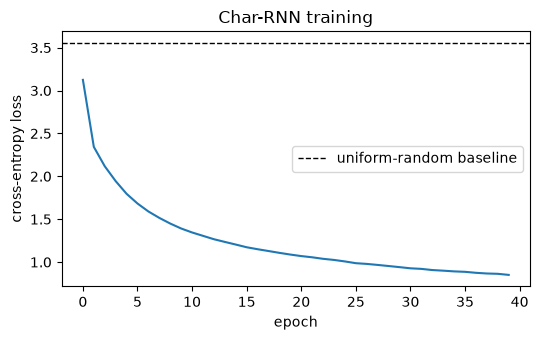

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(train_losses)
ax.axhline(np.log(VOCAB_SIZE), color="k", ls="--", lw=1, label="uniform-random baseline")
ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy loss"); ax.set_title("Char-RNN training")
ax.legend()
fig.tight_layout(); fig.savefig(FIGDIR / "char_rnn_training_curve.png", dpi=200)
plt.show()


> **Common errors — Section 1**
> - Computing loss over the **padding** positions too — `ignore_index` is
>   essential; without it, the model spends capacity learning to predict
>   padding, which carries no chemical information at all.
> - Shifting `inputs`/`targets` inconsistently — `inputs = batch[:, :-1]`,
>   `targets = batch[:, 1:]` must line up so that `targets[t]` really is the
>   character *after* `inputs[t]`; an off-by-one error here trains the model
>   to solve a subtly wrong problem while still (misleadingly) reducing loss.


### ✅ Check yourself — Section 1

Prints `Section 1 OK`. Final loss is well below the uniform-random baseline.


In [6]:
# --- checkpoint (do not edit) ---
assert len(train_losses) == N_EPOCHS
assert train_losses[-1] < np.log(VOCAB_SIZE) * 0.6
assert (FIGDIR / "char_rnn_training_curve.png").is_file()
print("Section 1 OK")


Section 1 OK


**Conceptual questions**


1. Why is $\ln(\text{VOCAB\_SIZE})$ exactly the cross-entropy loss of a model
   that outputs a uniform distribution over every token?
2. Teacher forcing shows the model the *true* previous character during
   training. What problem could this hide until you actually try to
   generate (Section 2)?


**Answers**


1. Cross-entropy for a single correct class $c$ under a uniform prediction
   is $-\log(1/\text{VOCAB\_SIZE}) = \log(\text{VOCAB\_SIZE})$ — a model that
   has learned nothing achieves exactly this value on average.
2. **Exposure bias**: during generation the model must condition on its
   *own*, possibly imperfect, previous outputs, which it never had to do
   during teacher-forced training — small early mistakes can compound as
   generation continues, a mismatch training loss alone does not reveal.


---
## 2. Sampling and assessing validity

To **generate**, feed `<start>`, sample one character from the model's
predicted distribution, feed that character back in, and repeat until
`<end>` or a maximum length — exactly the autoregressive process Week 08A's
equation $P(x_0,\ldots,x_L)=\prod_t P(x_t\mid x_{<t})$ describes, now actually
run.

We assess the result with the three standard generative-chemistry metrics:

* **Validity** — fraction that RDKit can parse as a molecule at all.
* **Uniqueness** — fraction of the *valid* ones that are distinct
  (canonicalised) structures.
* **Novelty** — fraction of the unique valid ones **not already in the
  training set** (a model that just memorised training molecules is not
  generating anything new).

**What to look for:** validity well above 0 but well below 100% — a genuine,
informative result, not a target to "fix" by post-hoc filtering.


In [7]:
def sample_smiles(model, max_len=MAX_LEN, temperature=1.0):
    """Autoregressively sample one SMILES string (stops at <end> or max_len)."""
    model.eval()
    generated = []
    state = None
    token = torch.tensor([[stoi[START]]])
    with torch.no_grad():
        for _ in range(max_len):
            logits, state = model(token, state)
            probs = F.softmax(logits[0, -1] / temperature, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).item()
            if next_id == stoi[END]:
                break
            generated.append(next_id)
            token = torch.tensor([[next_id]])
    return "".join(itos[i] for i in generated)


def assess_generated(smiles_samples, training_set):
    """(validity, uniqueness, novelty) fractions -- the standard generative-chemistry trio."""
    valid = [s for s in smiles_samples if Chem.MolFromSmiles(s) is not None]
    canonical_valid = [Chem.MolToSmiles(Chem.MolFromSmiles(s)) for s in valid]
    unique_valid = set(canonical_valid)
    training_canonical = set(training_set)          # already canonical (Week 02B)
    novel = unique_valid - training_canonical
    validity = len(valid) / len(smiles_samples)
    uniqueness = len(unique_valid) / len(valid) if valid else 0.0
    novelty = len(novel) / len(unique_valid) if unique_valid else 0.0
    return validity, uniqueness, novelty, unique_valid


torch.manual_seed(1)
generated_07 = [sample_smiles(rnn, temperature=0.7) for _ in range(100)]
validity, uniqueness, novelty, unique_valid_07 = assess_generated(generated_07, train_smiles)

print(f"validity:   {validity:.0%}")
print(f"uniqueness: {uniqueness:.0%} (of the valid ones)")
print(f"novelty:    {novelty:.0%} (of the unique valid ones)")
print("example generated SMILES:", generated_07[:8])


validity:   76%
uniqueness: 96% (of the valid ones)
novelty:    62% (of the unique valid ones)
example generated SMILES: ['CCCCCCCCCCCCCCCO', 'CCOP(=S)(OCC)OCC1(Cl)C(Cl)C(=O)C(O)C5C21C', 'CCCCC(=O)OCCC', 'CCCCCOC(=O)COC', 'O=C1(C)C(C2(C)CC3CC2(C)C(=O)CC3CC4CCC4(C)C(C)C(=O)CC21', 'C#CCCCC', 'Cc1cccc2ccccc12', 'CCC1(C)C(=O)C(=O)C1C']


> **Common errors — Section 2**
> - Reporting "uniqueness" or "novelty" as a fraction of **all** samples
>   rather than of the valid ones — a model with 10% validity could still
>   have 100% uniqueness *among those valid ones*, which is a different (and
>   equally important) statement from "10% of everything is unique".
> - Comparing generated SMILES strings to the training set **without
>   canonicalising both sides** — the same molecule written two different
>   ways would incorrectly count as "novel".


### ✅ Check yourself — Section 2

Prints `Section 2 OK`. Validity, uniqueness and novelty are all well-formed fractions, and validity is comfortably above 10%.


In [8]:
# --- checkpoint (do not edit) ---
assert 0.0 <= validity <= 1.0
assert 0.0 <= uniqueness <= 1.0
assert 0.0 <= novelty <= 1.0
assert validity > 0.1          # the model has learned *something* about SMILES syntax
print("Section 2 OK")


Section 2 OK


**Conceptual questions**


1. Why report validity, uniqueness *and* novelty, rather than just validity?
2. A generative model with 100% validity, 100% uniqueness, but 0% novelty
   would be behaving how, concretely?


**Answers**


1. Each answers a different question a chemist actually has: can I parse
   what came out at all (validity)? is it giving me the same handful of
   structures over and over (uniqueness)? and is it just reciting the
   training set back to me (novelty)? A model could score well on any one of
   these while failing badly on another.
2. It would be perfectly, reliably reproducing **training-set molecules
   only** — technically valid and internally consistent, but chemically
   useless as a generative model, since it has discovered nothing beyond
   what it was shown.


---
## 3. Temperature: the validity/diversity trade-off

`temperature` rescales the logits before `softmax`
($\mathrm{softmax}(\text{logits}/T)$): $T<1$ sharpens the distribution
towards the model's most confident guesses (more conservative, more likely
to reproduce familiar, valid-looking patterns); $T>1$ flattens it (more
exploratory, more likely to wander into syntactically broken territory).

**What to look for:** validity **falls** as temperature rises; uniqueness
(among the valid ones) tends to **rise** — a genuine trade-off, not a bug to
tune away.


In [9]:
torch.manual_seed(1)
temperatures = [0.5, 0.7, 1.0, 1.3]
temp_results = []
for T in temperatures:
    samples = [sample_smiles(rnn, temperature=T) for _ in range(100)]
    v, u, n, _ = assess_generated(samples, train_smiles)
    temp_results.append({"temperature": T, "validity": v, "uniqueness": u, "novelty": n})
    print(f"T={T}: validity={v:.0%}  uniqueness={u:.0%}  novelty={n:.0%}")

temp_df = pd.DataFrame(temp_results)


T=0.5: validity=91%  uniqueness=85%  novelty=55%
T=0.7: validity=65%  uniqueness=92%  novelty=52%
T=1.0: validity=36%  uniqueness=100%  novelty=69%
T=1.3: validity=12%  uniqueness=100%  novelty=75%


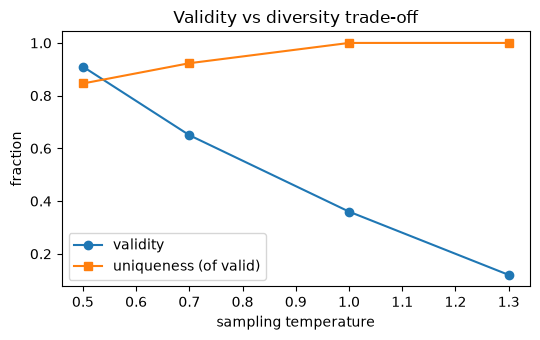

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(temp_df["temperature"], temp_df["validity"], "o-", label="validity")
ax.plot(temp_df["temperature"], temp_df["uniqueness"], "s-", label="uniqueness (of valid)")
ax.set_xlabel("sampling temperature"); ax.set_ylabel("fraction")
ax.set_title("Validity vs diversity trade-off"); ax.legend()
fig.tight_layout(); fig.savefig(FIGDIR / "validity_vs_temperature.png", dpi=200)
plt.show()


> **Common errors — Section 3**
> - Picking the single "best" temperature and reporting only that number —
>   the *trade-off curve* is the finding; the "right" temperature depends on
>   what you need (many safe, valid molecules vs a smaller number of more
>   diverse, riskier ones).
> - Comparing validity across temperatures using **different** random seeds
>   per temperature — always fix the seed (`torch.manual_seed(1)` before the
>   loop here) so the comparison isolates the effect of temperature alone.


### ✅ Check yourself — Section 3

Prints `Section 3 OK`. Validity at temperature 0.5 is higher than at temperature 1.3.


In [11]:
# --- checkpoint (do not edit) ---
assert len(temp_df) == 4
assert temp_df.loc[temp_df["temperature"] == 0.5, "validity"].iloc[0] > \
       temp_df.loc[temp_df["temperature"] == 1.3, "validity"].iloc[0]
assert (FIGDIR / "validity_vs_temperature.png").is_file()
print("Section 3 OK")


Section 3 OK


**Conceptual questions**


1. If you needed **one single, very likely valid** molecule for a follow-up
   experiment, which end of this trade-off would you sample from?
2. Why might a *pretrained* generative model (Week 08's ChemBERTa is
   encoder-only and not generative, but imagine a generative equivalent)
   show a gentler validity/temperature trade-off than this from-scratch
   40-epoch model?


**Answers**


1. Low temperature (e.g. 0.5) — accepting less diversity in exchange for a
   much higher chance any single sample is even chemically valid.
2. A model pretrained on a much larger, more diverse SMILES corpus for far
   longer has had more opportunity to internalise SMILES syntax robustly, so
   even its higher-temperature (more exploratory) samples are more likely to
   still respect basic syntactic constraints — this notebook's model has had
   only 40 epochs on ~1000 molecules to learn the same thing.


---
## 4. Do generated molecules resemble the training distribution?

Validity tells you a string *parses*; it says nothing about whether the
resulting molecules are chemically similar in **character** to what the
model was trained on. We compare the molecular-weight distribution of the
valid, unique, novel molecules from Section 2 (`temperature=0.7`) against the
training set's.

**What to look for:** overlapping but not identical histograms — the
generated set should resemble ESOL's overall size range, not concentrate on
implausibly tiny or huge structures.


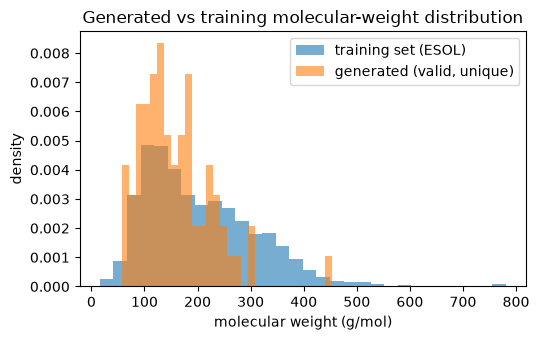

training MolWt:  mean=203.7  std=102.9
generated MolWt: mean=157.5  std=68.6


In [12]:
train_mw = [Descriptors.MolWt(Chem.MolFromSmiles(s)) for s in train_smiles]
generated_mw = [Descriptors.MolWt(Chem.MolFromSmiles(s)) for s in unique_valid_07]

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.hist(train_mw, bins=30, alpha=0.6, density=True, label="training set (ESOL)")
ax.hist(generated_mw, bins=30, alpha=0.6, density=True, label="generated (valid, unique)")
ax.set_xlabel("molecular weight (g/mol)"); ax.set_ylabel("density")
ax.set_title("Generated vs training molecular-weight distribution"); ax.legend()
fig.tight_layout(); fig.savefig(FIGDIR / "generated_property_distribution.png", dpi=200)
plt.show()

print(f"training MolWt:  mean={np.mean(train_mw):.1f}  std={np.std(train_mw):.1f}")
print(f"generated MolWt: mean={np.mean(generated_mw):.1f}  std={np.std(generated_mw):.1f}")


> **Common errors — Section 4**
> - Treating a close mean/std match as proof the generative model has
>   learned "real chemistry" — a model could match a size distribution while
>   still generating implausible functional-group combinations; a property
>   histogram is a **sanity check**, not a full validation.


### ✅ Check yourself — Section 4

Prints `Section 4 OK`. A histogram comparing the two molecular-weight distributions is saved.


In [13]:
# --- checkpoint (do not edit) ---
assert len(generated_mw) == len(unique_valid_07)
assert (FIGDIR / "generated_property_distribution.png").is_file()
print("Section 4 OK")


Section 4 OK


**Conceptual questions**


1. If the generated distribution were shifted to systematically **smaller**
   molecular weights than training, what would that suggest about the
   model's generation process?
2. Name one property besides molecular weight you would check for the same
   kind of sanity comparison.


**Answers**


1. It could suggest the model over-favours `<end>`/shorter completions
   (perhaps because shorter sequences are, on average, easier for a
   partially-trained model to get right, so they dominate what survives the
   validity filter) rather than genuinely sampling the full range of
   training-set chemistry.
2. LogP (does the generated set span a similarly lipophilic-to-polar range?),
   or the distribution of ring counts/aromatic character — anything with a
   known, checkable distribution in the training data.


---
## 5. Exercises


### Exercise 1 — greedy decoding vs sampling *(easy, ~12 min)*

Write `sample_smiles_greedy(model, max_len)` — like `sample_smiles` but
always picking the **most likely** next character (`argmax`) instead of
sampling. Generate 10 strings and note how many are *identical* to each
other (greedy decoding from the same fixed start is deterministic).

<details><summary>Show hint</summary>

Replace `torch.multinomial(probs, 1)` with `probs.argmax()`. Every call
should return the **same** string.
</details>


In [14]:
def sample_smiles_greedy(model, max_len=MAX_LEN):
    """Always pick the highest-probability next character (deterministic)."""
    model.eval()
    generated = []
    state = None
    token = torch.tensor([[stoi[START]]])
    with torch.no_grad():
        for _ in range(max_len):
            logits, state = model(token, state)
            next_id = logits[0, -1].argmax().item()
            if next_id == stoi[END]:
                break
            generated.append(next_id)
            token = torch.tensor([[next_id]])
    return "".join(itos[i] for i in generated)

greedy_samples = [sample_smiles_greedy(rnn) for _ in range(10)]
n_unique_greedy = len(set(greedy_samples))
print("greedy samples (should all be identical):", greedy_samples[:3])
print("unique greedy samples:", n_unique_greedy)


greedy samples (should all be identical): ['CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC', 'CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC', 'CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC']
unique greedy samples: 1


In [15]:
# --- check your answer (do not edit) ---
assert n_unique_greedy == 1        # greedy decoding from a fixed start is deterministic
print("Exercise 1 OK")


Exercise 1 OK


### Exercise 2 — length distribution of valid generations *(medium, ~15 min)*

Write `length_stats(smiles_list)` returning `(mean_length, max_length)` in
characters. Compare the length distribution of `unique_valid_07` (Section 2)
to the training set's.

<details><summary>Show hint</summary>

`[len(s) for s in smiles_list]`, then `np.mean`/`np.max`.
</details>


In [16]:
def length_stats(smiles_list):
    """(mean, max) SMILES string length in characters."""
    lengths = [len(s) for s in smiles_list]
    return np.mean(lengths), np.max(lengths)

mean_train, max_train = length_stats(train_smiles)
mean_gen, max_gen = length_stats(list(unique_valid_07))
print(f"training:  mean={mean_train:.1f}  max={max_train}")
print(f"generated: mean={mean_gen:.1f}  max={max_gen}")


training:  mean=22.6  max=97
generated: mean=15.2  max=35


In [17]:
# --- check your answer (do not edit) ---
assert mean_train > 0 and mean_gen > 0
assert max_gen <= MAX_LEN
print("Exercise 2 OK")


Exercise 2 OK


### Exercise 3 — a validity-only speed-up *(medium, ~15 min)*

Sampling one character at a time is slow for large sample counts. Write
`quick_validity(model, n_samples, temperature)` that samples `n_samples`
strings and returns **only** the validity fraction (skip uniqueness/novelty,
which need the extra canonicalisation bookkeeping) — useful for a fast
temperature scan before committing to the full three-metric assessment.

<details><summary>Show hint</summary>

Reuse `sample_smiles` in a loop; `sum(Chem.MolFromSmiles(s) is not None for s
in samples) / n_samples`.
</details>


In [18]:
def quick_validity(model, n_samples, temperature):
    """Validity fraction only, for a fast temperature scan."""
    samples = [sample_smiles(model, temperature=temperature) for _ in range(n_samples)]
    n_valid = sum(Chem.MolFromSmiles(s) is not None for s in samples)
    return n_valid / n_samples

torch.manual_seed(2)
quick_scan = {T: quick_validity(rnn, 30, T) for T in [0.4, 0.6, 0.9, 1.2]}
print(quick_scan)


{0.4: 0.9, 0.6: 0.8333333333333334, 0.9: 0.26666666666666666, 1.2: 0.16666666666666666}


In [19]:
# --- check your answer (do not edit) ---
assert set(quick_scan) == {0.4, 0.6, 0.9, 1.2}
assert all(0.0 <= v <= 1.0 for v in quick_scan.values())
print("Exercise 3 OK")


Exercise 3 OK


### 🏁 Mini-challenge — a curated, trustworthy generated set *(~20 min)*

Combine everything this notebook has built: generate a batch of molecules at
your best temperature, then filter to only those that are simultaneously
**valid**, **novel** (not in the training set) and **within a plausible size
range** (say, molecular weight between 50 and 500 g/mol — Week 04A's
Lipinski-adjacent territory). Report how many survive out of how many
sampled.

Write `curated_generation(model, n_samples, temperature, mw_range)` returning
the list of surviving canonical SMILES.


Implement `curated_generation` below.


In [20]:
def curated_generation(model, n_samples, temperature, mw_range=(50, 500)):
    """Sample n_samples molecules; keep only valid + novel + in mw_range."""
    samples = [sample_smiles(model, temperature=temperature) for _ in range(n_samples)]
    training_canonical = set(train_smiles)
    survivors = []
    for s in samples:
        mol = Chem.MolFromSmiles(s)
        if mol is None:
            continue
        canonical = Chem.MolToSmiles(mol)
        if canonical in training_canonical:
            continue
        mw = Descriptors.MolWt(mol)
        if mw_range[0] <= mw <= mw_range[1]:
            survivors.append(canonical)
    return survivors

torch.manual_seed(3)
curated = curated_generation(rnn, n_samples=150, temperature=0.7)
print(f"{len(curated)} / 150 samples survived the valid+novel+plausible-size filter")
print(curated[:5])


42 / 150 samples survived the valid+novel+plausible-size filter
['C=CCC(C)C', 'CNCC(=O)NC(=O)NC(=O)Nc1ccccc1', 'C=CC(=O)CC', 'Nc1ccc(O)c(=O)cc1', 'CNC(=O)Nc1ccccc1']


In [21]:
# --- check your answer (do not edit) ---
assert isinstance(curated, list)
assert all(Chem.MolFromSmiles(s) is not None for s in curated)
assert all(s not in set(train_smiles) for s in curated)
print("Mini-challenge OK")


Mini-challenge OK


---
## Summary — what you learned

- A **reduced-epoch budget** pattern for a training-from-scratch (not just
  inference) notebook that runs comfortably on a laptop CPU.
- A **character-level generative RNN**, trained with teacher forcing on
  exactly the autoregressive objective Week 08A defined, then actually
  **sampled** — temperature-controlled, one character at a time.
- The standard **validity / uniqueness / novelty** evaluation trio for
  generative chemistry, and the genuine **validity/diversity trade-off**
  across sampling temperature.
- A property-distribution sanity check, and a curated-filtering pipeline
  combining validity, novelty and a plausible size range.

This closes the deep-learning arc of the course (Weeks 05-09): MLPs, GNNs,
attention/transformers, and now generation. Week 10 turns to frontier
applications, common pitfalls, and the module's mini-project hackathon.


## Further reading (course source list only)

- dmol.pub, in-browser generative RNN demo (*MolGenerator*):
  <https://dmol.pub/applied/MolGenerator.html>
- Colab alternative (EPFL *AI for Chemistry*, molecular generative models /
  SMILES-LSTM walkthrough):
  <https://colab.research.google.com/github/schwallergroup/ai4chem_course/blob/main/notebooks/05%20-%20Generative%20Models/Molecular%20Generative%20Models.ipynb>,
  <https://colab.research.google.com/github/schwallergroup/ai4chem_course/blob/main/notebooks/06%20-%20Generative%20Models%202/SMILES-LSTM-Walkthrough.ipynb>


## Attribution

Original teaching material for *AI for Chemistry*, adapted and rewritten from:

- **dmol.pub** (A. White) — the autoregressive next-token-prediction framing
  (Week 08A) directly underlies this session's training objective; the
  in-browser *MolGenerator* demo is the course's inspiration for a
  from-scratch, in-notebook character-RNN generator rather than an external
  service. CC-BY 4.0. <https://dmol.pub>
- **EPFL CH-457 *AI for Chemistry*** (Schwaller group) — SMILES-LSTM
  generative-modelling framing. MIT licence.
  <https://github.com/schwallergroup/ai4chem_course>

Continues the ESOL SMILES strings and tokenisation pattern from Weeks 02-03
and 08A. No verbatim text is reproduced from the sources above.
